### 오차 역전파
 - 순전파 : 입력 데이터를 입력층에서 출력층까지 정방향으로 이동시키며 출력값을 예측하는 과정
   - 예측하는 과정
 - 역전파 : 출력층에서 발생한 에러를 입력층으로 전파시키면서 최적의 결과를 학습해 나가는 과정
   - 최적의 방향으로 학습하는 과정

 - batch_size : 한번의 epoch로는 모든 데이터를 학습하기 어렵기 때문에 나눠서 학습하는 방법
   - batch_size가 작을수록 메모리 소모는 작음, 학습속도는 빠르나 정확도는 줄어들 수 있음
   - batch_size가 클수록 메모리 소모는 큼, 학습속도는 빠르나 정확도는 줄어들 수 있음

### 최적화 함수 종류 (Optimizer)
 - SGD (확률적 경사 하강법)
   - 오차를 줄여나갈 수 있도록 확률적으로 선택된 일부 데이터를 업데이트하여 학습하는 방법
 - 모멘텀(Momentum)
   - 경사하강법에서 가중치를 수정할 때 이전 방향을 참고하여 업데이트 하는 방법
   - 지그재그현상을 줄일 수 있음
   - 학습속도가 가속화 될 가능성이 있음
 - Adagrad
   - 학습을 진행함에 있어 학습률을 점차 줄여나가는 방법
   - 처음에는 학습률을 크게 학습하여 가중치 변동을 크게 진행하고 점점 작게 학습하여 오차에 대해 최적의 해를 찾앙 나가는 방법
   - 학습속도가 빠르고 정확하다는 장점이 있음
 - Adam
   - 학습에 대해서 학습률을 점차 줄여나가면서 방향 또한 이전 방향을 참고하여 최적의 해를 찾아 나가는 방법
   - 현재 가장 많이 사용하는 방법 (장점만을 모았음)

### 오늘의 목표
 - 패션데이터를 가지고 활성화함수, 최적화 함수를 변화시키면서 결과를 확인해보는 실습을 진행하기

In [1]:
# 드라이브 마운트

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive/Colab Notebooks/딥러닝

/content/drive/MyDrive/Colab Notebooks/딥러닝


In [5]:
!pwd

/content/drive/MyDrive/Colab Notebooks/딥러닝


In [6]:
# 데이터 다루기 위해 불러오는 라이브러리

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
# 데이터 가져오기
# sklearn에서 데이터를 제공했듯이 tensorflow에서도 데이터셋을 제공해준다.
# tensorflow에 있는 패션데이터를 불러와보기

from tensorflow.keras.datasets import fashion_mnist

In [8]:
# 데이터 로드

data = fashion_mnist.load_data()
data

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [9]:
# 데이터 분할 (X_train, X_test, y_train, y_test)

X_train = data[0][0]
y_train = data[0][1]
X_test = data[1][0]
y_test = data[1][1]

In [11]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

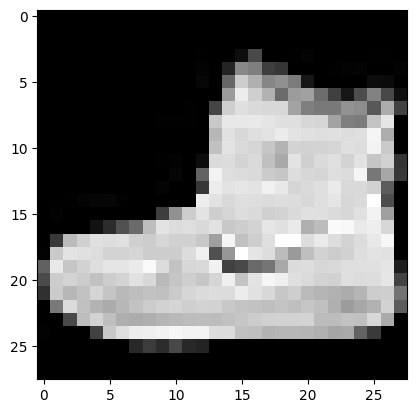

In [12]:
plt.imshow(X_train[0], cmap = 'gray')

In [14]:
# 정답 데이터확인

np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

### 정답데이터 분류
- 0 : 티셔츠
- 1 : 트라우저(바지)
- 2 : 단추가 없는 스웨터
- 3 : 드레스
- 4 : 코트
- 5 : 샌들
- 6 : 셔츠
- 7 : 스니커즈
- 8 : 가방
- 9 : 앵클 부츠

In [15]:
y_train[0]

np.uint8(9)

### 신경망 구축
 - 데이터 전처리 진행
 - MLP 구성

### 이미지 데이터
 - 이미지는 2차원(흑백) 또는 3차원(컬러) 형태를 가진다.
 - MLP는 1차원 데이터만 학습이 가능하다.
 - 이미지 데이터의 차원을 1차원으로 변경해야만 학습이 가능
 - reshape : 데이터의 형태를 변형할 수 있는 기능

### 이미지 전처리 진행
 - MLP를 사용하기 위해 이미지의 차원을 1차원으로 변경 (reshape 사용)

In [17]:
# (28,28) => 1차원(784) 변경 진행

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [18]:
# 데이터 변형하기

X_train_rs = X_train.reshape(60000, 784)

# X_train.reshape(60000, -1)


X_test_rs = X_test.reshape(10000, 784)

# X_test.reshape(10000, -1)

In [19]:
# 크기확인

print(X_train_rs.shape)
print(X_test_rs.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 784)
(10000, 784)
(60000,)
(10000,)


### 정답 데이터 변경
 - softmax(다중분류)를 사용하기 위해서는 정답데이터를 원-핫-인코딩을 해야만 사용할 수 있다.
 - 따라서 y_train, y_test를 원-핫-인코딩 진행하기

In [21]:
# 원-핫-인코딩 진행

y_train_one_hot = pd.get_dummies(y_train)
y_test_one_hot = pd.get_dummies(y_test)

In [22]:
y_train_one_hot.head()

,0,1,2,3,4,5,6,7,8,9
0,False,False,False,False,False,False,False,False,False,True
1,True,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False


### 신경망 설계 (MLP)
 - 활성화 함수와 최적화 함수를 설정하여 성능비교 진행

### 1. 활성화 함수 : sigmoid / 최적화 함수 : SGD

In [25]:
# 모델을 사용하기 위한 도구 불러오기

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import InputLayer
from tensorflow.keras.optimizers import SGD, Adam

In [27]:
# 신경망 설계
# 뼈대 구축

model1 = Sequential()


# 입력층

model1.add(InputLayer(shape = (784, )))

# InputLayer는 입력층을 받기 위한 층이기 때문에 MLP에 전달할 때 원하는 크기로 받을 수 있음
# 우리가 사용할 때 shape = (28,28)로 사용이 가능하다.
# 대신 Flatten층을 추가
# Flatten : 입력받은 층으로부터 데이터를 1차원으로 변경해서 사용하는 기능


# 중간층

model1.add(Dense(100, activation = 'sigmoid'))
model1. add(Dense(200, activation = 'sigmoid'))
model1. add(Dense(100, activation = 'sigmoid'))


# 출력층

model1.add(Dense(10, activation = 'softmax'))

In [28]:
# 학습방법 및 평가방법 설정

model1.compile(
    loss = 'categorical_crossentropy',
    optimizer = SGD(),
    metrics = ['accuracy']
)

In [29]:
# 학습 진행

model1.fit(
    X_train_rs,
    y_train_one_hot,
    validation_split = 0.2,   # 검증 데이터 비율
    epochs = 20,   # 학습횟수
    batch_size = 64   # 배치사이즈 설정
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3235 - loss: 2.2223 - val_accuracy: 0.3973 - val_loss: 2.1305
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3991 - loss: 1.9708 - val_accuracy: 0.4963 - val_loss: 1.7896
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.4862 - loss: 1.6474 - val_accuracy: 0.5773 - val_loss: 1.5243
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5707 - loss: 1.4291 - val_accuracy: 0.5938 - val_loss: 1.3324
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6069 - loss: 1.2542 - val_accuracy: 0.6344 - val_loss: 1.1729
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6397 - loss: 1.1111 - val_accuracy: 0.6643 - val_loss: 1.0436
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6662 - loss: 0.9958 - val_accuracy: 0.6767 - val_loss: 0.9413
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6910 - loss: 0.9061 - val_accuracy: 0.

In [ ]:
# 최적화 함수 사용 방법
# optimizer = SGD()
# 항급률 조정을 하고싶을 경우
# SGD(learning_rate = 0.01) => 0.01 or 0.001 많이 사용 (모델마다 다름)
# 모멘텀 방법으로 학습을 진행하고 싶은 경우
# SGD(learning_rate = 0.01, momentum = 0.09)   # 모멘텀 지수는 일반적으로 0.9를 사용

### activation = sigmoid / optimizer = 모멘텀 사용

In [30]:
# 신경망 설계

print(X_train.shape)
print(X_train_rs.shape)

(60000, 28, 28)
(60000, 784)


In [31]:
# 만약에 이미지 데이터를 사용할 때 1차원으로 변경을 하지 못하고 사용할 경우
# Flatten을 이용하여 1차원으로 전달하는 방법이 존재

from tensorflow.keras.layers import Flatten

In [34]:
# 뼈대 생성

model2 = Sequential()


# 입력층

model2.add(Flatten(input_shape = (28, 28)))

# Flatten을 이용하여 1차원으로 변경하여 다음층으로 데이터를 전달


# 중간층
model2.add(Dense(100, activation = 'sigmoid'))
model2.add(Dense(200, activation = 'sigmoid'))
model2.add(Dense(100, activation = 'sigmoid'))


# 출력층

model2.add(Dense(10, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
# 학습방법 및 평가방법 설정 (모멘텀 사용)

model2.compile(
    loss = 'categorical_crossentropy',
    optimizer = SGD(learning_rate = 0.01, momentum = 0.9),
    metrics = ['accuracy']
)

In [36]:
# 학습

model2.fit(
    X_train, y_train_one_hot,
    validation_split = 0.2,
    epochs = 20,
    batch_size = 64
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4788 - loss: 1.5052 - val_accuracy: 0.6055 - val_loss: 1.0359
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6304 - loss: 1.0133 - val_accuracy: 0.6149 - val_loss: 1.0091
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5612 - loss: 1.1443 - val_accuracy: 0.4883 - val_loss: 1.1644
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4745 - loss: 1.3152 - val_accuracy: 0.4619 - val_loss: 1.3485
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3970 - loss: 1.4506 - val_accuracy: 0.4058 - val_loss: 1.3375
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4175 - loss: 1.3895 - val_accuracy: 0.3498 - val_loss: 1.7310
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3527 - loss: 1.5585 - val_accuracy: 0.3108 - val_loss: 1.8474
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3703 - loss: 1.4931 - val_accuracy: 0.

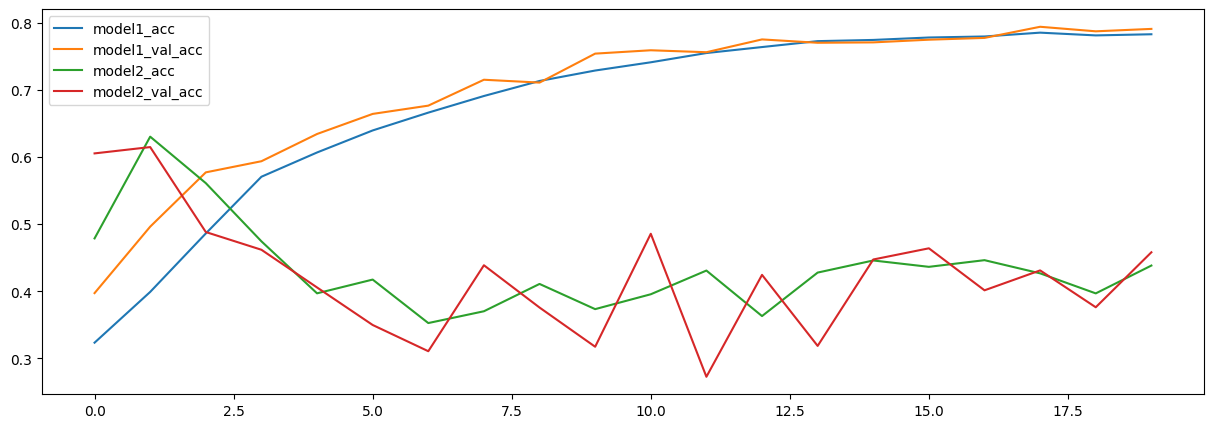

In [41]:
# 2가지 모델 결과 비교

plt.figure(figsize = (15, 5))


# 1번모델 (sigmoid + SGD)

plt.plot(model1.history.history['accuracy'], label = 'model1_acc')
plt.plot(model1.history.history['val_accuracy'], label = 'model1_val_acc')


# 2번보델 (sigmoid + 모멘텀)

plt.plot(model2.history.history['accuracy'], label = 'model2_acc')
plt.plot(model2.history.history['val_accuracy'], label = 'model2_val_acc')

plt.legend()
plt.show()

### 실습
 3. 모델 : activation : sigmoid / optimizer : Adam
 4. 모델 : activation : relu / optimizer : SGD
 5. 모델 : activation : relu / optimizer : Adam

In [60]:
# 모델 : activation : sigmoid / optimizer : Adam
# 뼈대 생성

model3 = Sequential()


# 입력층

model3.add(InputLayer(input_shape = (784,)))

# Flatten을 이용하여 1차원으로 변경하여 다음층으로 데이터를 전달


# 중간층
model3.add(Dense(100, activation = 'sigmoid'))
model3.add(Dense(200, activation = 'sigmoid'))
model3.add(Dense(100, activation = 'sigmoid'))


# 출력층

model3.add(Dense(10, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [61]:
# 학습방법 및 평가방법 설정 (모멘텀 사용)

model3.compile(
    loss = 'categorical_crossentropy',
    optimizer = Adam(),
    metrics = ['accuracy']
)

In [62]:
# 학습 진행

model3.fit(
    X_train_rs,
    y_train_one_hot,
    validation_split = 0.2,   # 검증 데이터 비율
    epochs = 20,   # 학습횟수
    batch_size = 64   # 배치사이즈 설정
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6276 - loss: 1.0248 - val_accuracy: 0.7221 - val_loss: 0.7705
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7022 - loss: 0.7748 - val_accuracy: 0.7073 - val_loss: 0.7354
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6962 - loss: 0.7716 - val_accuracy: 0.7178 - val_loss: 0.7163
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7014 - loss: 0.7477 - val_accuracy: 0.7150 - val_loss: 0.7397
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7173 - loss: 0.7193 - val_accuracy: 0.7216 - val_loss: 0.7141
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7284 - loss: 0.6977 - val_accuracy: 0.7458 - val_loss: 0.6730
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7362 - loss: 0.6870 - val_accuracy: 0.7393 - val_loss: 0.6817
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7284 - loss: 0.7039 - val_accuracy: 0.

In [63]:
# 모델 : activation : relu / optimizer : SGD
# 뼈대 생성

model4 = Sequential()


# 입력층

model4.add(InputLayer(input_shape = (784,)))

# Flatten을 이용하여 1차원으로 변경하여 다음층으로 데이터를 전달


# 중간층
model4.add(Dense(100, activation = 'relu'))
model4.add(Dense(200, activation = 'relu'))
model4.add(Dense(100, activation = 'relu'))


# 출력층

model4.add(Dense(10, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [64]:
# 학습방법 및 평가방법 설정 (모멘텀 사용)

model4.compile(
    loss = 'categorical_crossentropy',
    optimizer = SGD(),
    metrics = ['accuracy']
)

In [65]:
# 학습 진행

model4.fit(
    X_train_rs,
    y_train_one_hot,
    validation_split = 0.2,   # 검증 데이터 비율
    epochs = 20,   # 학습횟수
    batch_size = 64   # 배치사이즈 설정
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 9/20
750/750 ━━━━━

In [66]:
# 모델 : activation : relu / optimizer : Adam
# 뼈대 생성

model5 = Sequential()


# 입력층

model5.add(InputLayer(input_shape = (784,)))

# Flatten을 이용하여 1차원으로 변경하여 다음층으로 데이터를 전달


# 중간층
model5.add(Dense(100, activation = 'relu'))
model5.add(Dense(200, activation = 'relu'))
model5.add(Dense(100, activation = 'relu'))


# 출력층

model5.add(Dense(10, activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [67]:
# 학습방법 및 평가방법 설정 (모멘텀 사용)

model5.compile(
    loss = 'categorical_crossentropy',
    optimizer = Adam(),
    metrics = ['accuracy']
)

In [68]:
# 학습 진행

model5.fit(
    X_train_rs,
    y_train_one_hot,
    validation_split = 0.2,   # 검증 데이터 비율
    epochs = 20,   # 학습횟수
    batch_size = 64   # 배치사이즈 설정
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7371 - loss: 1.7504 - val_accuracy: 0.7997 - val_loss: 0.6074
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8069 - loss: 0.5490 - val_accuracy: 0.8186 - val_loss: 0.5161
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8283 - loss: 0.4804 - val_accuracy: 0.8333 - val_loss: 0.4789
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8414 - loss: 0.4410 - val_accuracy: 0.8472 - val_loss: 0.4385
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8506 - loss: 0.4119 - val_accuracy: 0.8482 - val_loss: 0.4266
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8566 - loss: 0.3907 - val_accuracy: 0.8486 - val_loss: 0.4266
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8599 - loss: 0.3853 - val_accuracy: 0.8393 - val_loss: 0.4622
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8666 - loss: 0.3637 - val_accuracy: 0.

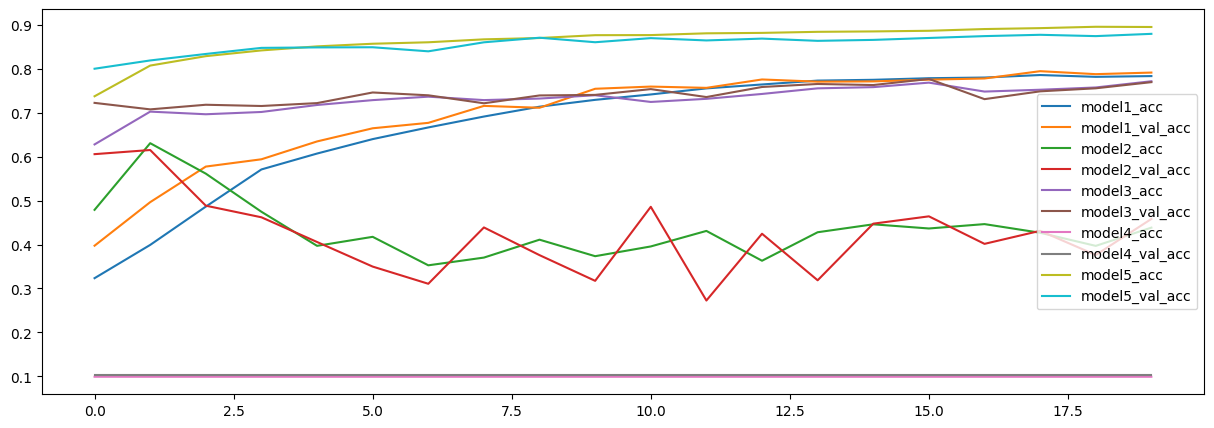

In [69]:
# 5가지 모델 결과 비교

plt.figure(figsize = (15, 5))


# 1번모델 (sigmoid + SGD)

plt.plot(model1.history.history['accuracy'], label = 'model1_acc')
plt.plot(model1.history.history['val_accuracy'], label = 'model1_val_acc')


# 2번보델 (sigmoid + 모멘텀)

plt.plot(model2.history.history['accuracy'], label = 'model2_acc')
plt.plot(model2.history.history['val_accuracy'], label = 'model2_val_acc')

# 3번보델 (sigmoid + Adam)

plt.plot(model3.history.history['accuracy'], label = 'model3_acc')
plt.plot(model3.history.history['val_accuracy'], label = 'model3_val_acc')

# 4번보델 (relu + SGD)

plt.plot(model4.history.history['accuracy'], label = 'model4_acc')
plt.plot(model4.history.history['val_accuracy'], label = 'model4_val_acc')

# 5번보델 (relu + Adam)

plt.plot(model5.history.history['accuracy'], label = 'model5_acc')
plt.plot(model5.history.history['val_accuracy'], label = 'model5_val_acc')


plt.legend()
plt.show()
